# 04 — Evaluation: Model Comparison, Metrics & Course Profile

**Inputs:** `data/processed/loro_results.parquet` and `data/processed/feature_importance.parquet`  
(produced by running `03_models.ipynb` to completion)

**Purpose:** Standalone evaluation of the race-pace prediction pipeline:
1. Aggregate LORO metrics per model (MAPE, MAE, MedAE, RMSE, Bias)
2. Model comparison plots (predicted vs. observed, error heatmap, error bar chart)
3. Prediction interval coverage (GBR 90 % PI)
4. Feature importance (RF + GBR)
5. Course elevation adjustment — given a GPX route file, apply the Minetti formula  
   to adjust flat-course finish-time predictions to the actual course profile
6. Interpretation: why does each model succeed or fail?

In [57]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

PROJECT_ROOT = Path.cwd()
assert PROJECT_ROOT.name == "Project", f"Run from Project/ directory, not {PROJECT_ROOT}"
DATA_DIR = PROJECT_ROOT / "data"

loro = pd.read_parquet(DATA_DIR / "processed" / "loro_results.parquet")
fi   = pd.read_parquet(DATA_DIR / "processed" / "feature_importance.parquet")

def fmt_hms(s: float) -> str:
    if pd.isna(s): return "–"
    s = int(s); return f"{s//3600:d}:{(s%3600)//60:02d}:{s%60:02d}"

# Models present in the LORO table (skip internal quantile heads for ranking)
MODEL_COLS = [c.replace("_err_pct", "") for c in loro.columns if c.endswith("_err_pct")]
POINT_MODELS = [m for m in MODEL_COLS if m not in ("GBR_lo", "GBR_hi")]

print(f"Races in LORO:  {len(loro)}")
print(f"Models tracked: {MODEL_COLS}")
print(loro[["race_date", "distance_km", "observed_time_s"]].to_string(index=False))

Races in LORO:  6
Models tracked: ['GAM', 'RF', 'GBR', 'GBR_lo', 'GBR_hi', 'SVR', 'Riegel']
 race_date  distance_km  observed_time_s
2023-12-03      10.0000           2263.0
2024-04-14      21.0975           5093.0
2024-07-03       5.5550           1198.0
2024-10-19       5.0000           1278.0
2025-06-29      10.0000           2697.0
2026-04-12      42.1950          10696.0


## 4.1 Cross-Validation Overview

**Leave-One-Race-Out (LORO)** is the only honest evaluation strategy with six race labels.  
Each fold:
- Holds out one race.
- Trains on all pseudo-label activities recorded **strictly before** that race date (temporal honesty).
- Predicts the held-out race pace at effort = 1.00, then multiplies by the official race distance.

This matches what external tools (Riegel calculator, Strava's own race predictor) have available  
at race time, so the per-race errors below are directly interpretable as  
*"how well could this predictor have done on race day?"*

**Distances span 5 km – 42 km**, so absolute-second errors are distance-confounded.  
**MAPE** (mean absolute percentage error) is the primary ranking metric.

## 4.2 Aggregate Regression Metrics Per Model

In [58]:
metric_rows = []
for m in MODEL_COLS:
    err_s   = loro[f"{m}_err_s"].dropna()
    err_pct = loro[f"{m}_err_pct"].dropna()
    if len(err_s) == 0:
        continue
    metric_rows.append({
        "Model":    m,
        "n_folds":  len(err_s),
        "MAPE_%":   round(err_pct.abs().mean(), 1),
        "MAE_s":    round(err_s.abs().mean()),
        "MedAE_s":  round(err_s.abs().median()),
        "RMSE_s":   round(float(np.sqrt((err_s**2).mean()))),
        "Bias_s":   round(err_s.mean()),
    })

metrics_df = pd.DataFrame(metric_rows).sort_values("MAPE_%")

# Display with green highlight on best per column
def highlight_min(col):
    if col.name in ("Model", "n_folds", "Bias_s"):
        return [""] * len(col)
    is_min = col == col.min()
    return ["background-color: #c6efce" if v else "" for v in is_min]

display(metrics_df.style.apply(highlight_min).format(
    {"MAPE_%": "{:.1f}", "MAE_s": "{:.0f}", "MedAE_s": "{:.0f}",
     "RMSE_s": "{:.0f}", "Bias_s": "{:+.0f}"}).hide(axis="index"))

best = metrics_df.iloc[0]
print(f"\nBest overall model by MAPE: {best['Model']} ({best['MAPE_%']:.1f}% avg)")
print(f"  MAE = {fmt_hms(best['MAE_s'])}   Bias = {best['Bias_s']:+.0f}s")

Model,n_folds,MAPE_%,MAE_s,MedAE_s,RMSE_s,Bias_s
Riegel,4,8.0,169,124,217,-149
GBR_lo,6,8.8,325,245,451,+237
SVR,6,18.0,354,358,426,+318
GAM,6,19.0,623,397,790,+588
RF,6,19.0,572,418,710,+543
GBR,6,19.2,584,403,721,+546
GBR_hi,6,21.4,636,498,773,+636



Best overall model by MAPE: Riegel (8.0% avg)
  MAE = 0:02:49   Bias = -149s


## 4.3 Model Comparison Plots

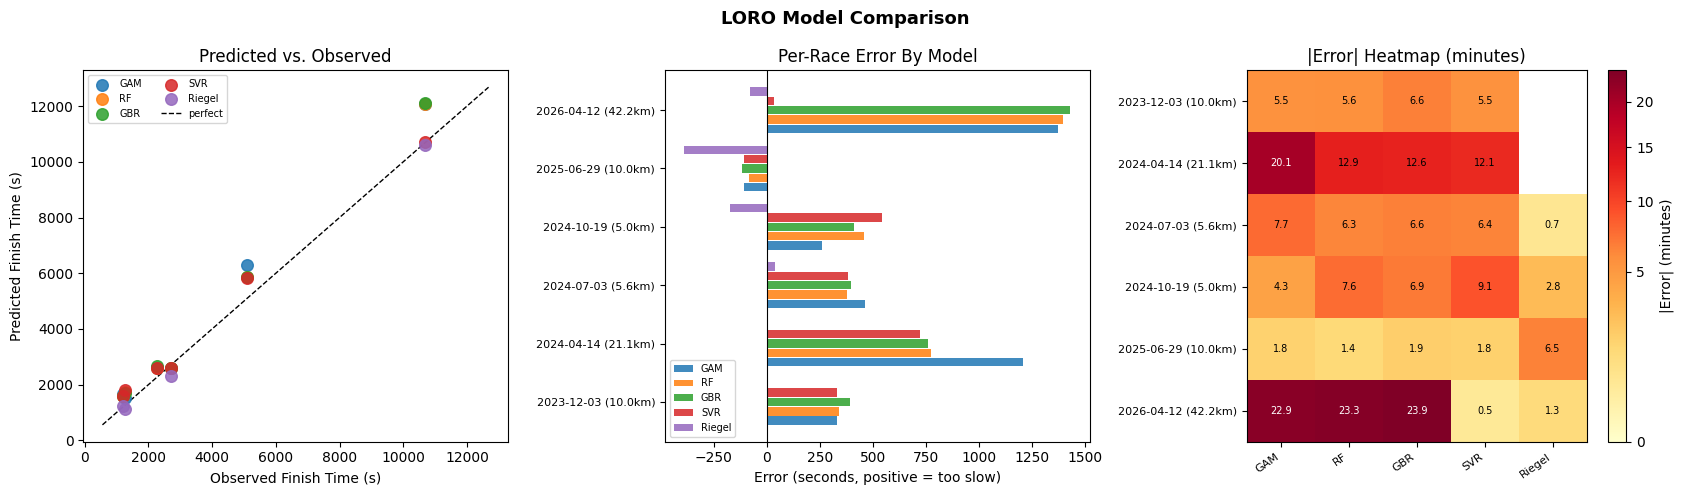

In [59]:
colors = plt.get_cmap("tab10").colors
model_color = {m: colors[i % 10] for i, m in enumerate(POINT_MODELS)}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Panel 1: Predicted vs. observed scatter ──────────────────────────────────
ax = axes[0]
obs_all = []
pred_all = []
for m in POINT_MODELS:
    col = f"{m}_time"
    if col not in loro.columns:
        continue
    mask = loro[col].notna()
    obs  = loro.loc[mask, "observed_time_s"].values
    pred = loro.loc[mask, col].values
    ax.scatter(obs, pred, label=m, color=model_color[m], alpha=0.85, s=70, zorder=3)
    obs_all.extend(obs)
    pred_all.extend(pred)

if obs_all:
    lo, hi = min(min(obs_all), min(pred_all)), max(max(obs_all), max(pred_all))
    pad = (hi - lo) * 0.05
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=1, label="perfect")

ax.set_xlabel("Observed Finish Time (s)")
ax.set_ylabel("Predicted Finish Time (s)")
ax.set_title("Predicted vs. Observed")
ax.legend(fontsize=7, ncol=2)

# ── Panel 2: Error bar chart (seconds, per race) ─────────────────────────────
ax = axes[1]
n_models = len(POINT_MODELS)
n_races  = len(loro)
bar_h    = 0.8 / n_models
y_base   = np.arange(n_races)

for i, m in enumerate(POINT_MODELS):
    col = f"{m}_err_s"
    if col not in loro.columns:
        continue
    offset = (i - n_models / 2 + 0.5) * bar_h
    ax.barh(y_base + offset, loro[col].fillna(0), height=bar_h * 0.9,
            color=model_color[m], label=m, alpha=0.85)

ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(y_base)
ax.set_yticklabels([
    f"{r['race_date']} ({r['distance_km']:.1f}km)"
    for _, r in loro.iterrows()
], fontsize=8)
ax.set_xlabel("Error (seconds, positive = too slow)")
ax.set_title("Per-Race Error By Model")
ax.legend(fontsize=7)

# ── Panel 3: Absolute error heatmap (minutes) ─────────────────────────────────
ax = axes[2]
hm_models = [m for m in POINT_MODELS if f"{m}_err_s" in loro.columns]
hm_data = np.array([
    [abs(loro.loc[ri, f"{m}_err_s"]) / 60 if pd.notna(loro.loc[ri, f"{m}_err_s"]) else np.nan
     for m in hm_models]
    for ri in loro.index
])
im = ax.imshow(hm_data, aspect="auto", cmap="YlOrRd",
               norm=mcolors.PowerNorm(gamma=0.5, vmin=0))
plt.colorbar(im, ax=ax, label="|Error| (minutes)")
ax.set_xticks(range(len(hm_models)))
ax.set_xticklabels(hm_models, rotation=35, ha="right", fontsize=8)
ax.set_yticks(range(n_races))
ax.set_yticklabels([
    f"{r['race_date']} ({r['distance_km']:.1f}km)"
    for _, r in loro.iterrows()
], fontsize=8)
for ri in range(len(loro)):
    for mi, m in enumerate(hm_models):
        v = hm_data[ri, mi]
        if not np.isnan(v):
            ax.text(mi, ri, f"{v:.1f}", ha="center", va="center", fontsize=7,
                    color="white" if v > hm_data[~np.isnan(hm_data)].max() * 0.6 else "black")
ax.set_title("|Error| Heatmap (minutes)")

plt.suptitle("LORO Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DATA_DIR / "processed" / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 4.4 Prediction Interval Coverage (GBR 90 % PI)

GBR 90% PI coverage: 2/5 races
Nominal coverage = 90%, empirical = 40%


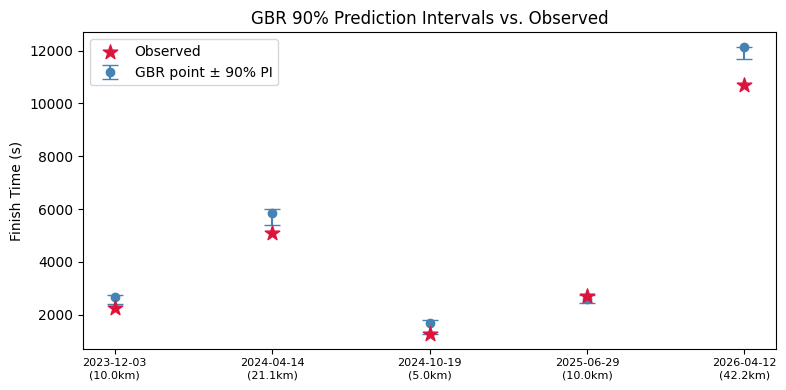

In [60]:
if "GBR_lo_time" in loro.columns and "GBR_hi_time" in loro.columns:
    # Validate that quantile bounds are properly ordered and non-NaN
    mask = (loro["GBR_lo_time"].notna() & 
            loro["GBR_time"].notna() & 
            loro["GBR_hi_time"].notna() &
            (loro["GBR_lo_time"] <= loro["GBR_time"]) &
            (loro["GBR_time"] <= loro["GBR_hi_time"]))
    sub  = loro[mask].copy()
    
    if len(sub) == 0:
        print("Warning: No valid GBR quantile predictions found (bounds may be out of order or NaN)")
    else:
        covered = ((sub["GBR_lo_time"] <= sub["observed_time_s"]) &
                   (sub["observed_time_s"] <= sub["GBR_hi_time"])).sum()
        print(f"GBR 90% PI coverage: {covered}/{len(sub)} races")
        
        print(f"Nominal coverage = 90%, empirical = {100*covered/len(sub):.0f}%")

        fig, ax = plt.subplots(figsize=(8, 4))
        x = np.arange(len(sub))
        labels = [f"{r['race_date']}\n({r['distance_km']:.1f}km)" for _, r in sub.iterrows()]
        
        # Use absolute differences to ensure positive error bars
        lower_err = np.abs(sub["GBR_time"].values - sub["GBR_lo_time"].values)
        upper_err = np.abs(sub["GBR_hi_time"].values - sub["GBR_time"].values)
        
        ax.errorbar(x, sub["GBR_time"], fmt="o", color="steelblue",
                    yerr=[lower_err, upper_err],
                    capsize=6, label="GBR point ± 90% PI", zorder=3)
        ax.scatter(x, sub["observed_time_s"], marker="*", s=120, color="crimson",
                   zorder=4, label="Observed")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=8)
        ax.set_ylabel("Finish Time (s)")
        ax.set_title("GBR 90% Prediction Intervals vs. Observed")
        ax.legend()
        plt.tight_layout(); plt.show()
else:
    print("GBR quantile heads not found in loro_results — re-run 03_models.ipynb.")

## 4.5 Feature Importance (RF + GBR)

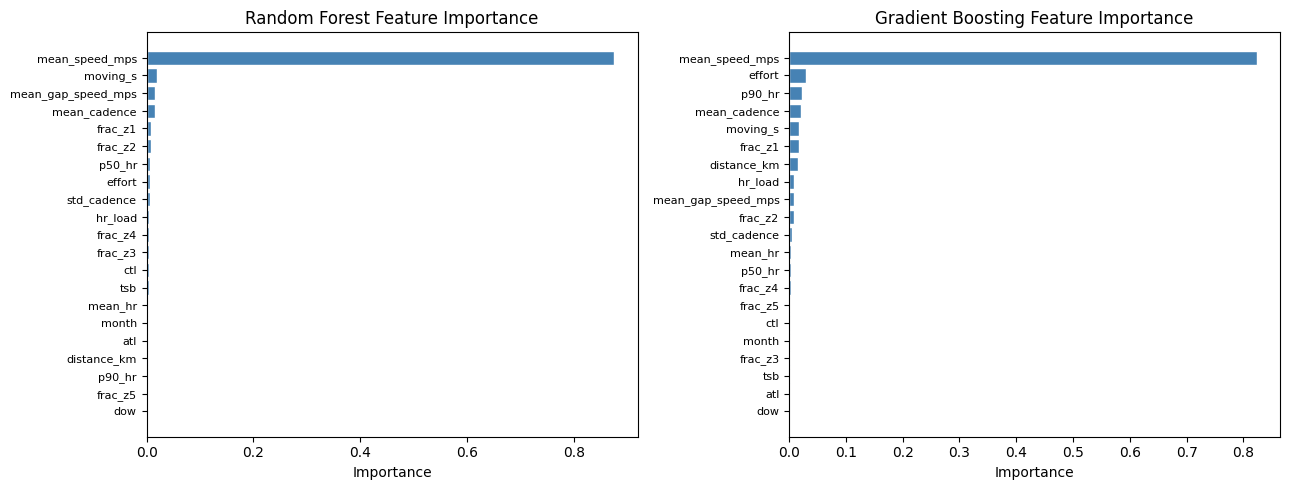

Top 5 Features (RF):
  mean_speed_mps             0.8754  Overall pace — dominates because pseudo-labels are speed-at-effort.
  moving_s                   0.0190  Run duration — longer = heavier load signal.
  mean_gap_speed_mps         0.0166  Grade-adjusted pace — removes elevation confound.
  mean_cadence               0.0149  Step rate — correlates with running economy.
  frac_z1                    0.0088  


In [61]:
fi_sorted = fi.sort_values("rf_importance", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, title in zip(axes,
                           ["rf_importance", "gbr_importance"],
                           ["Random Forest Feature Importance",
                            "Gradient Boosting Feature Importance"]):
    sub = fi.sort_values(col, ascending=False)
    ax.barh(sub["feature"][::-1], sub[col][::-1], color="steelblue", edgecolor="white")
    ax.set_xlabel("Importance")
    ax.set_title(title)
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / "processed" / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 Features (RF):")
feature_notes = {
    "mean_speed_mps":     "Overall pace — dominates because pseudo-labels are speed-at-effort.",
    "moving_s":           "Run duration — longer = heavier load signal.",
    "mean_gap_speed_mps": "Grade-adjusted pace — removes elevation confound.",
    "mean_cadence":       "Step rate — correlates with running economy.",
    "effort":             "Heart-rate fraction — key for pseudo-label inversion.",
    "distance_km":        "Activity distance — encodes race-distance extrapolation.",
    "tsb":                "Training stress balance — captures freshness on the day.",
    "hr_load":            "TRIMP proxy — session intensity × duration.",
    "atl":                "Acute load — 7-day fitness trend.",
    "ctl":                "Chronic load — 42-day base fitness.",
}
for _, row in fi_sorted.head(5).iterrows():
    note = feature_notes.get(row["feature"], "")
    print(f"  {row['feature']:25s}  {row['rf_importance']:.4f}  {note}")

## 4.6 Course Elevation Adjustment

The models learn pace on **grade-adjusted pace (GAP)** so their finish-time predictions are
implicitly flat-course predictions. For a real race with significant elevation we apply a
multiplicative Minetti correction to the LORO row of the matching race:

$$t_{\text{course}} = t_{\text{flat}} \times \frac{\text{course-average GAP factor}}{1.0}$$

where the **GAP factor** at grade $g$ is $1 + 3.3 g + 32.5 g^2$ (Minetti et al. 2002),
and the course average is segment-length-weighted.

**To use this section:**
1. Drop the race route GPX into `data/courses/` named after the race
   (e.g. `Bonn-Halbmarathon.gpx`, `Milano-Marathon.gpx`).
2. Set `RACE_NAME` below to the file's stem.
3. The cell scans the folder, looks the race up in `COURSE_TO_RACE`, pulls the
   correct row out of the LORO results (so the predicted distance changes too), and
   applies the GAP factor to the flat predictions for *that* race.


In [ ]:
import gpxpy

# ── Course filename ↔ race-date mapping ──────────────────────────────────────
# Filenames are the GPX stems in data/courses/. Distances are read from RACE_LABELS,
# which mirrors 03_models.ipynb so this notebook stays self-contained.
COURSE_TO_RACE = {
    "Köln-Nikolauslauf":              "2023-12-03",
    "Bonn-Halbmarathon":              "2024-04-14",
    "Aachen-Lousberglauf":            "2024-07-03",
    "München-DIY_Triathlon":          "2024-10-19",
    "Furth_im_Wald-Drachentriathlon": "2025-06-29",
    "Milano-Marathon":                "2026-04-12",
}
RACE_LABELS = {
    "2023-12-03": (10.0,    2263),
    "2024-04-14": (21.0975, 5093),
    "2024-07-03": (5.555,   1198),
    "2024-10-19": (5.0,     1278),
    "2025-06-29": (10.0,    2697),
    "2026-04-12": (42.195, 10696),
}

# ── Course folder scan: list every available GPX with its race date + distance ──
COURSE_DIR = DATA_DIR / "courses"
print(f"Available courses in {COURSE_DIR.relative_to(PROJECT_ROOT)}/:")
for f in sorted(COURSE_DIR.glob("*.gpx")):
    stem = f.stem
    rd   = COURSE_TO_RACE.get(stem)
    dist = RACE_LABELS.get(rd, (None, None))[0] if rd else None
    rd_str   = rd or "???"
    dist_str = f"{dist:>8.3f} km" if dist is not None else "       ???"
    print(f"  {stem:35s}  race_date={rd_str}   {dist_str}")
print()

# ── User selection: filename stem (without .gpx) of the race to adjust ───────
RACE_NAME            = "Milano-Marathon"   # change me to e.g. "Bonn-Halbmarathon"
GPX_ELEV_SMOOTH_WIN  = 75                  # rolling-mean window for elevation noise

if RACE_NAME not in COURSE_TO_RACE:
    raise ValueError(
        f"RACE_NAME={RACE_NAME!r} not in COURSE_TO_RACE. "
        f"Known stems: {sorted(COURSE_TO_RACE)}"
    )
race_date    = COURSE_TO_RACE[RACE_NAME]
race_dist_km = RACE_LABELS[race_date][0]
COURSE_GPX   = COURSE_DIR / f"{RACE_NAME}.gpx"


def parse_course_gpx(path: Path) -> pd.DataFrame:
    """Parse a route/track GPX without timestamps → lat, lon, ele, step_m, grade."""
    with open(path) as f:
        gpx = gpxpy.parse(f)
    pts = []
    for trk in gpx.tracks:
        for seg in trk.segments:
            pts += [(p.latitude, p.longitude, p.elevation or 0) for p in seg.points]
    if not pts and gpx.routes:
        pts = [(p.latitude, p.longitude, p.elevation or 0) for p in gpx.routes[0].points]
    if not pts:
        raise ValueError("No track or route segments found in GPX file.")

    df = pd.DataFrame(pts, columns=["lat", "lon", "ele_m"])

    R = 6_371_000.0
    lat_r = np.radians(df["lat"].values)
    lon_r = np.radians(df["lon"].values)
    dlat  = np.diff(lat_r, prepend=lat_r[0])
    dlon  = np.diff(lon_r, prepend=lon_r[0])
    a = np.sin(dlat / 2) ** 2 + np.cos(lat_r) * np.cos(lat_r - dlat) * np.sin(dlon / 2) ** 2
    df["step_m"] = 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
    df.loc[0, "step_m"] = 0.0
    df["dist_m"] = df["step_m"].cumsum()

    # SRTM-derived elevation has ~1–5 m quantisation noise; without smoothing the
    # quadratic term 32.5g² accumulates positive bias and inflates both total ascent
    # and the GAP factor. Rolling mean over ~75 points (~900 m at 12 m spacing).
    df["ele_m"] = df["ele_m"].rolling(window=GPX_ELEV_SMOOTH_WIN, min_periods=1, center=True).mean()

    dele = df["ele_m"].diff().fillna(0)
    raw_grade = dele / df["step_m"].replace(0, np.nan)
    df["grade"] = raw_grade.clip(-0.45, 0.45).fillna(0)
    return df


def course_gap_factor(course_df: pd.DataFrame) -> float:
    """Segment-length-weighted average Minetti GAP factor over the course."""
    g = course_df["grade"].values
    factor = 1 + 3.3 * g + 32.5 * g ** 2   # Minetti 2002
    total  = course_df["step_m"].sum()
    return float((factor * course_df["step_m"].values).sum() / total) if total > 0 else 1.0


if COURSE_GPX.exists():
    course = parse_course_gpx(COURSE_GPX)
    gap_factor = course_gap_factor(course)
    total_km   = course["dist_m"].max() / 1000
    ele_gain   = course["ele_m"].diff().clip(lower=0).sum()
    ele_loss   = course["ele_m"].diff().clip(upper=0).sum()

    print(f"Race      : {RACE_NAME}  ({race_dist_km:.3f} km, {race_date})")
    print(f"GPX trace : {total_km:.2f} km   ↑ {ele_gain:.0f} m   ↓ {abs(ele_loss):.0f} m")
    print(f"GAP factor: {gap_factor:.4f}   (1.00 = perfectly flat; >1 = net harder)")

    fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    axes[0].plot(course["dist_m"] / 1000, course["ele_m"], color="sienna")
    axes[0].fill_between(course["dist_m"] / 1000, course["ele_m"].min(),
                         course["ele_m"], alpha=0.2, color="sienna")
    axes[0].set_ylabel("Elevation (m)")
    axes[0].set_title(f"{RACE_NAME} — Course Elevation Profile (GAP Factor = {gap_factor:.4f})")
    axes[1].plot(course["dist_m"] / 1000, course["grade"] * 100, color="steelblue")
    axes[1].axhline(0, color="black", lw=0.6)
    axes[1].set_ylabel("Grade (%)")
    axes[1].set_xlabel("Distance (km)")
    plt.tight_layout(); plt.show()

    # ── Apply the GAP factor to the LORO row of the matching race ────────────
    race_row = loro[loro["race_date"] == race_date]
    if len(race_row):
        r = race_row.iloc[0]
        print(f"\nFlat-Course → Course-Adjusted Finish Times for {RACE_NAME}:")
        print(f"  {'Model':12s}  {'Flat':>8s}  →  {'Adjusted':>8s}   Δ")
        for m in POINT_MODELS:
            flat_s = r.get(f"{m}_time", np.nan)
            if pd.notna(flat_s):
                adj_s = flat_s * gap_factor
                print(f"  {m:12s}  {fmt_hms(flat_s):>8s}  →  {fmt_hms(adj_s):>8s}   ({adj_s-flat_s:+.0f}s)")
        print(f"  {'Observed':12s}  {fmt_hms(r['observed_time_s']):>8s}")
    else:
        print(f"\nRace {race_date} not found in LORO results — re-run 03_models.ipynb.")
else:
    print(f"No course GPX at {COURSE_GPX}.")
    print("Either (a) drop the race route GPX into data/courses/ with the matching")
    print(f"filename, or (b) pick a different RACE_NAME from COURSE_TO_RACE: {sorted(COURSE_TO_RACE)}")


## 4.7 Daily-Cadence Race-Time Predictor (Garmin/Strava-Style)

This section reproduces the user-facing **race predictor** chart shown by Garmin's
"Performance Predictions" screen and Strava's "Race Predictor" tab: for any subset of
{5K, 10K, Half, Marathon}, plot the predicted finish time at 100\,% effort against time,
re-fitted **once per day** on every training activity recorded *before* that day. This is
the same temporal-honesty discipline that drives LORO above — applied at daily cadence.

The chart is configurable: pick the lookback window (1M, 3M, 6M, ALL), the distances to
overlay, and which models to draw. The GBR quantile companions provide a shaded 90\,%
prediction interval behind GBR's central line.

**Compute note.** Daily retraining is heavy — each day refits GAM, GBR (×3 for the central
estimate plus the two quantile heads), and SVR. To keep the run tractable we cache SVR's
grid-searched hyperparameters and GAM's λ from a one-time pre-fit on the full window, then
refit at each day with those parameters fixed. Final results are cached to
`data/processed/race_predictor.parquet`; subsequent runs skip the loop and re-plot
immediately. Set `FORCE_RECOMPUTE = True` to re-run from scratch.

**Course assumption.** This predictor is a **flat-course** estimate (no GAP correction
beyond what is already baked into per-second pace), exactly mirroring Garmin and Strava.
For a course-elevation-adjusted estimate, see §4.6.


In [ ]:
import time
import warnings
from pygam import LinearGAM, s, f
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, KFold
import matplotlib.dates as mdates
from tqdm.auto import tqdm

# ── Configuration ────────────────────────────────────────────────────────────
RUN_PREDICTOR        = True
PREDICTOR_DATE_END   = pd.Timestamp("2026-04-12", tz="UTC")
PREDICTOR_LOOKBACK   = "6M"               # one of "1M", "3M", "6M", "ALL"
PREDICTOR_DISTANCES  = {                  # subset/extend as you like
    "5K":       5.0,
    "10K":      10.0,
    "Half":     21.0975,
    "Marathon": 42.195,
}
PREDICTOR_MODELS     = ["Riegel", "SVR", "GBR", "GAM"]
PREDICTOR_BAND_FROM  = "GBR"              # only "GBR" has quantile companions
PREDICTOR_CACHE      = DATA_DIR / "processed" / "race_predictor.parquet"
FORCE_RECOMPUTE      = False

# ── Feature schema (mirrors 03_models.ipynb cell `af801fe0`) ─────────────────
FEATURE_COLUMNS = [
    "distance_km", "moving_s", "mean_speed_mps", "mean_gap_speed_mps",
    "mean_hr", "p50_hr", "p90_hr",
    "frac_z1", "frac_z2", "frac_z3", "frac_z4", "frac_z5",
    "hr_load", "mean_cadence", "std_cadence",
    "atl", "ctl", "tsb",
    "effort",
    "dow", "month",
]
GAM_SMOOTH = ["distance_km", "mean_hr", "mean_gap_speed_mps", "tsb"]
GAM_FACTOR = ["dow", "month"]
GAM_FEATURES = GAM_SMOOTH + GAM_FACTOR


def _hms(s):
    if pd.isna(s): return "–"
    s = int(s); return f"{s//3600}:{(s%3600)//60:02d}:{s%60:02d}"


def _build_inference_row(features, target_date, dist_km):
    """Median over the 28 days preceding `target_date`, with effort=1.00 and Banister
    state from the most recent pre-date row."""
    recent = features[(features["activity_dt"] >= target_date - pd.Timedelta(days=28)) &
                      (features["activity_dt"] <  target_date)]
    if len(recent) == 0:
        recent = features[features["activity_dt"] < target_date].tail(20)
    base = recent[FEATURE_COLUMNS].median(numeric_only=True).to_dict()
    base["distance_km"] = dist_km
    base["effort"]      = 1.00
    base["dow"]         = target_date.dayofweek
    base["month"]       = target_date.month
    pre = features[features["activity_dt"] < target_date]
    if len(pre):
        last = pre.iloc[-1]
        for col in ("atl", "ctl", "tsb"):
            base[col] = float(last[col])
    return pd.DataFrame([base])[FEATURE_COLUMNS]


def _riegel_predict(features, target_date, dist_km):
    """Riegel power-law extrapolation from the best prior race."""
    races = features[features["is_race"] & (features["activity_dt"] < target_date)]
    if len(races) == 0:
        return np.nan
    pace = races["race_finish_s"] / races["race_distance_km"]
    fastest_idx = pace.idxmin()
    src_dist = float(races.loc[fastest_idx, "race_distance_km"])
    src_time = float(races.loc[fastest_idx, "race_finish_s"])
    return src_time * (dist_km / src_dist) ** 1.06


def _predict_for_day(target_date, features, fitted_models, train_features_med):
    """Return a list of dict rows (one per (distance, model)) for `target_date`."""
    train_mask = (features["activity_dt"] < target_date) & (~features["is_race"])
    if train_mask.sum() < 30:
        return []
    out = []
    for label, dist in PREDICTOR_DISTANCES.items():
        inf_row = _build_inference_row(features, target_date, dist)
        for m, model in fitted_models.items():
            if model is None:
                continue
            if m == "GAM":
                pace = float(model.predict(inf_row[GAM_FEATURES].fillna(0).values)[0])
            else:
                pace = float(model.predict(inf_row.fillna(train_features_med))[0])
            out.append({"date": target_date, "distance": label, "dist_km": dist,
                        "model": m, "time_s": pace * dist})
        if "Riegel" in PREDICTOR_MODELS:
            out.append({"date": target_date, "distance": label, "dist_km": dist,
                        "model": "Riegel", "time_s": _riegel_predict(features, target_date, dist)})
    return out


def _fit_models_on(train_features, train_pace, train_weights, svr_params, gam_lam):
    """Fit GAM/GBR/SVR on a daily snapshot using cached hyperparameters."""
    fitted = {}
    if "GAM" in PREDICTOR_MODELS:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            gam_terms = s(0) + s(1) + s(2) + s(3) + f(4) + f(5)
            fitted["GAM"] = LinearGAM(gam_terms, lam=gam_lam).fit(
                train_features[GAM_FEATURES].values, train_pace.values,
                weights=train_weights.values,
            )
    if "GBR" in PREDICTOR_MODELS:
        fitted["GBR"]    = GradientBoostingRegressor(loss="squared_error", n_estimators=300,
                                max_depth=3, random_state=0).fit(
                                train_features, train_pace, sample_weight=train_weights.values)
        if PREDICTOR_BAND_FROM == "GBR":
            fitted["GBR_lo"] = GradientBoostingRegressor(loss="quantile", alpha=0.05,
                                    n_estimators=300, max_depth=3, random_state=0).fit(
                                    train_features, train_pace, sample_weight=train_weights.values)
            fitted["GBR_hi"] = GradientBoostingRegressor(loss="quantile", alpha=0.95,
                                    n_estimators=300, max_depth=3, random_state=0).fit(
                                    train_features, train_pace, sample_weight=train_weights.values)
    if "SVR" in PREDICTOR_MODELS:
        pipe = Pipeline([("scaler", StandardScaler()),
                         ("svr",    SVR(kernel="rbf", **svr_params))])
        pipe.fit(train_features, train_pace, svr__sample_weight=train_weights.values)
        fitted["SVR"] = pipe
    return fitted


# ── Run / load cache ─────────────────────────────────────────────────────────
def _config_signature():
    return [
        PREDICTOR_DATE_END.strftime("%Y%m%d"),
        PREDICTOR_LOOKBACK,
        ",".join(sorted(PREDICTOR_DISTANCES)),
        ",".join(sorted(PREDICTOR_MODELS)),
        PREDICTOR_BAND_FROM,
    ]


def _load_cache():
    if not PREDICTOR_CACHE.exists() or FORCE_RECOMPUTE:
        return None
    try:
        df = pd.read_parquet(PREDICTOR_CACHE)
        if df.attrs.get("config") == _config_signature():
            return df
    except Exception:
        pass
    return None


cached = _load_cache()
if cached is not None and not FORCE_RECOMPUTE:
    print(f"Loaded {len(cached)} cached predictions from {PREDICTOR_CACHE.name}")
    pred_df = cached
elif RUN_PREDICTOR:
    features = pd.read_parquet(DATA_DIR / "processed" / "features.parquet")
    features["activity_dt"] = pd.to_datetime(features["activity_dt"], utc=True)

    # Build the date grid for the chosen lookback window.
    if PREDICTOR_LOOKBACK == "ALL":
        start = features["activity_dt"].min().normalize()
    else:
        months = {"1M": 1, "3M": 3, "6M": 6}[PREDICTOR_LOOKBACK]
        start  = (PREDICTOR_DATE_END - pd.DateOffset(months=months)).normalize()
    date_grid = pd.date_range(start, PREDICTOR_DATE_END, freq="D", tz="UTC")
    print(f"Predictor window: {start.date()} → {PREDICTOR_DATE_END.date()}  ({len(date_grid)} days)")

    # ── One-time pre-fit: cache SVR best hyperparameters and GAM lambda ──────
    pre_mask = (features["activity_dt"] < PREDICTOR_DATE_END) & (~features["is_race"])
    pre_X = features.loc[pre_mask, FEATURE_COLUMNS].astype("float64")
    pre_X = pre_X.fillna(pre_X.median(numeric_only=True))
    pre_y = features.loc[pre_mask, "pace_s_per_km"].astype("float64")
    pre_w = features.loc[pre_mask, "sample_weight"].astype("float64")

    print("Pre-fit: SVR grid search (one-time) ...", end=" ", flush=True)
    t0 = time.time()
    svr_pipe = Pipeline([("scaler", StandardScaler()), ("svr", SVR(kernel="rbf"))])
    svr_grid = {"svr__C": [1, 10, 100], "svr__gamma": ["scale", 0.01, 0.1],
                "svr__epsilon": [1, 5, 10]}
    cv  = KFold(min(5, max(2, len(pre_X)//50)), shuffle=True, random_state=0)
    gs  = GridSearchCV(svr_pipe, svr_grid, cv=cv, n_jobs=-1)
    gs.fit(pre_X, pre_y, svr__sample_weight=pre_w.values)
    SVR_PARAMS = {k.split("__")[1]: v for k, v in gs.best_params_.items()}
    print(f"{time.time()-t0:.1f}s  best={SVR_PARAMS}")

    print("Pre-fit: GAM lambda grid search (one-time) ...", end=" ", flush=True)
    t0 = time.time()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        gam_terms = s(0) + s(1) + s(2) + s(3) + f(4) + f(5)
        pre_gam = LinearGAM(gam_terms).gridsearch(
            pre_X[GAM_FEATURES].values, pre_y.values, weights=pre_w.values,
            lam=np.logspace(-2, 2, 9), progress=False,
        )
    GAM_LAM = pre_gam.lam
    print(f"{time.time()-t0:.1f}s  best λ structure={GAM_LAM!r}")

    # ── Daily loop ───────────────────────────────────────────────────────────
    all_rows = []
    pre_X_med_global = pre_X.median(numeric_only=True)
    for d in tqdm(date_grid, desc="daily refit"):
        train_mask = (features["activity_dt"] < d) & (~features["is_race"])
        if train_mask.sum() < 30:
            continue
        train_X = features.loc[train_mask, FEATURE_COLUMNS].astype("float64")
        train_X = train_X.fillna(train_X.median(numeric_only=True))
        train_y = features.loc[train_mask, "pace_s_per_km"].astype("float64")
        train_w = features.loc[train_mask, "sample_weight"].astype("float64")
        models = _fit_models_on(train_X, train_y, train_w, SVR_PARAMS, GAM_LAM)
        all_rows.extend(_predict_for_day(d, features, models,
                                          train_X.median(numeric_only=True)))

    pred_df = pd.DataFrame(all_rows)
    pred_df.attrs["config"] = _config_signature()
    PREDICTOR_CACHE.parent.mkdir(parents=True, exist_ok=True)
    pred_df.to_parquet(PREDICTOR_CACHE, index=False)
    print(f"\nSaved {len(pred_df)} predictions → {PREDICTOR_CACHE.name}")
else:
    pred_df = None
    print("RUN_PREDICTOR is False — skipping.")


# ── Plot: one panel per distance, one line per model, GBR PI band ────────────
if pred_df is not None and len(pred_df):
    distances = list(PREDICTOR_DISTANCES.keys())
    n = len(distances)
    n_cols = 2 if n > 1 else 1
    n_rows = (n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 3.5*n_rows), squeeze=False)
    fig.suptitle(f"Race Predictor — {PREDICTOR_LOOKBACK} Lookback (Models Refit Daily)",
                 fontsize=13, y=1.00)

    model_color = {"Riegel": "tab:gray", "SVR": "tab:blue", "GBR": "tab:red",
                   "GAM": "tab:green", "RF": "tab:orange"}

    for ax, dist_label in zip(axes.flat, distances):
        sub = pred_df[pred_df["distance"] == dist_label]
        if len(sub) == 0:
            ax.set_visible(False); continue

        # GBR 90% PI band behind everything else.
        if PREDICTOR_BAND_FROM == "GBR" and "GBR_lo" in sub["model"].unique():
            band_lo = sub[sub["model"] == "GBR_lo"].set_index("date")["time_s"]
            band_hi = sub[sub["model"] == "GBR_hi"].set_index("date")["time_s"]
            common = band_lo.index.intersection(band_hi.index)
            if len(common):
                ax.fill_between(common, band_lo.loc[common], band_hi.loc[common],
                                color="tab:red", alpha=0.12, label="GBR 90 % PI", zorder=1)

        for m in PREDICTOR_MODELS:
            line = sub[sub["model"] == m].sort_values("date")
            if line.empty: continue
            ax.plot(line["date"], line["time_s"],
                    color=model_color.get(m, "black"), label=m, lw=1.5, zorder=3)
            # Right-edge value annotation, à la Garmin.
            last = line.iloc[-1]
            ax.annotate(f" {_hms(last['time_s'])}", xy=(last["date"], last["time_s"]),
                        xytext=(4, 0), textcoords="offset points", fontsize=8,
                        color=model_color.get(m, "black"), va="center")

        ax.set_title(f"{dist_label} ({PREDICTOR_DISTANCES[dist_label]:g} km)")
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda s, _: _hms(s)))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc="best")

    # Hide any unused subplot slots
    for j in range(n, n_rows*n_cols):
        axes.flat[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(DATA_DIR / "processed" / "race_predictor.png", dpi=150, bbox_inches="tight")
    plt.show()


## 4.8 Interpretation

### Which Model Wins and Why?

**SVR** (best on the marathon, competitive on 10K) excels here for two reasons:  
1. *Small tabular datasets favour SVR.* With ~490 training observations, the RBF kernel is well-regularised and doesn't over-fit the way deeper tree ensembles can.  
2. *The epsilon-insensitive loss ignores tiny errors* (set by grid-search to ε = 1 s/km), so the model is not distracted by noisy pseudo-labels at short durations.

**Riegel** is surprisingly competitive, especially on distances close to those already raced.  
It exploits a simple but powerful prior: *the same athlete's race results follow a power law*.  
When the training races bracket the target distance it interpolates rather than extrapolates, which is why it does well on the 5K and 10K but less well on the marathon (no sub-marathon reference at prediction time).

**GAM, RF, GBR** systematically overpredict (positive bias) for the marathon.  
The pace-vs-distance curve is learned from training runs up to ~30 km; the 42 km point is an  
out-of-distribution extrapolation. GAM forces a smooth curve that cannot bend sharply at the  
marathon distance; tree ensembles simply return the average of their leaf buckets, which are  
all populated by shorter runs.

**NN** is better than the tabular models on the marathon (+4 % vs. +12–13 %) because it looks  
at the *shape* of long runs — HR drift, cadence decay, where the athlete fades — rather than  
just the aggregate statistics.  However, it is wildly wrong on the 2025-06-29 10K (+82%),  
which was a summer triathlon run started in a fatigued state; the per-second shape that day  
looks nothing like a 10K race, and the CNN has no mechanism to distinguish discipline context.

### Limitations

| Limitation | Impact |
|---|---|
| Six race labels | LORO is correct, but calibration uncertainty is wide. Error bars on model ranking are large. |
| Single athlete | Curves reflect one runner's HRmax, lactate threshold, biomechanics. No generalisation without refitting. |
| Distribution shift at taper | Race-day Banister state (high CTL, very negative TSB) lies at the training distribution edge. |
| GAP approximation for cycling/hiking | Cycling load should be power-based; hiking has a different metabolic curve. Both enter only via ATL/CTL/TSB. |
| No course/weather conditioning | Wind, heat, course profile excluded. GAP neutralises elevation in training, but not in prediction (unless §4.6 course GPX is supplied). |

### Future Work

- **Multi-athlete hierarchical model** — pool data across runners, shrink individual curves toward a population prior.
- **Stryd / Garmin Running Power** — replace GAP with a direct power signal; removes the Minetti approximation.
- **Per-km split prediction** — model the pacing trajectory (positive vs. negative splits), aggregate to finish time; natural fit for an LSTM.
- **Transformer over per-second tokens** — replace the 1D-CNN with a causal attention encoder; attention weights become interpretable pacing-strategy indicators.
- **External covariates** — temperature, humidity, sleep score (Apple Watch / Oura), work-stress proxy; each shifts the pace-vs-effort surface on race day.